In [2]:
import sys
sys.path.insert(0,r"C:\Users\Mayank\Desktop\RAJALI 2025\Fly-By-Data-main\main libraries") # folder which has main loading libs
import mavlab
import senlab
import matplotlib.pyplot as plt
import numpy as np
import datetime

In [17]:
# log_filename = '12 Dec_Flight2_3KM.beach.bin-1239127.mat' ## Through the clouds

log_filename='2025-12-14 12-55-20.bin-1820656.mat'

log_path = r"D:\parundu 2025 files\log matlab files parandu"
params = ['AHR2','ATT','BARO_0','BAT_0','GPS_0','XKF1_0','RATE','RCOU']
log_filename  = '//'.join(log_path.split('\\')[:]) + '//' + log_filename

data = mavlab.data(log_filename,params)
time = mavlab.timedata_gpscor(log_filename,params)

Loading Data from Log File		: 100%|████████████████████████████████████████████████████████████
Loading Time Data from Log File		: 100%|████████████████████████████████████████████████████████████


In [18]:
# sen_filename='cleaned_12 Dec_Flight2_3KM_Beach.csv'   ## Through the clouds
# sen_filename= 'cleaned_13 Dec_Flight1_3km_in_ocean_beach.csv'

sen_filename = 'cleaned_F1_FORENOON_3KM.csv'
sen_path = r"D:\parundu 2025 files\Cleaned Sensor file Parandu"
sen_filename  = '//'.join(sen_path.split('\\')[:]) + '//' + sen_filename
sen_data = senlab.tsm_data_simple(sen_filename)
sen_data_inter = senlab.read_csv_interp(sen_filename,5,10)
print(sen_data_inter.columns.tolist())


Loading Data from Sensor File		: 100%|████████████████████████████████████████████████████████████

['Wind Speed (m/s)', 'Horizontal Wind Direction (Degrees)', 'U Vector (m/s)', 'W Vector (m/s)', 'Temperature (TSM) (C)', 'Relative Humidity (TSM) (%)', 'Absolute Pressure (TSM) (hPa)', 'Pitch Angle (Degrees)', 'Roll Angle (Degrees)', 'Temperature (AHT10) (C)', 'Relative Humidity (AHT10) (%)', 'Temperature (MS5611) (C)', 'Absolute Pressure (MS5611) (hPa)']


In [ ]:
# Headers of CSV file:
# 'Time Stamp'	'Wind Speed (m/s)'	'Horizontal Wind Direction (Degrees)'	'U Vector (m/s)'	'V Vector (m/s)'	'W Vector (m/s)'	'Temperature (TSM) (C)'	'Relative Humidity (TSM) (%)'	'Absolute Pressure (TSM) (hPa)'	'Pitch Angle (Degrees)'	'Roll Angle (Degrees)'	'Temperature (AHT10) (C)'	'Relative Humidity (AHT10) (%)'	'Temperature (MS5611) (C)'	'Absolute Pressure (MS5611) (hPa)'

# Put the required header below to extract data
pressure = np.array(sen_data_inter['Absolute Pressure (TSM) (hPa)'])
# pressure = np.array(sen_data['Absolute Pressure (TSM) (hPa)'])
alt = np.array(data['XKF1_0']['PD'])
wind = np.array(sen_data_inter['Wind Speed (m/s)'])
temp = np.array(sen_data_inter['Temperature (AHT10) (C)'])
rh= np.array(sen_data_inter['Relative Humidity (AHT10) (%)'])
rh_tsm= np.array(sen_data_inter['Relative Humidity (TSM) (%)'])
u_vector = np.array(sen_data_inter['U Vector (m/s)'])
# v_vector = np.array(sen_data_inter['V Vector (m/s)'])
w_vector = np.array(sen_data_inter['W Vector (m/s)'])

# print(sen_time[-5:])
# print(time['XKF1_0'][-5:])

n =3450
y = 0
x = len(alt) + n + y

# pressure2 = np.array(pressure[n:x])
# alt2 = np.array(alt[y:x])

# Case 1
# pressure2 = pressure[:len(alt)]
# # alt2 = alt[:len(pressure2)]
# alt2 = alt[n:n+len(pressure2)]

#Case 2
pressure2 = pressure[n:n+len(alt)]
alt2 =-1*alt[:len(pressure2)]
wind2 = wind[n:n+len(alt)]
temp2 = temp[n:n+len(alt)]
rh2 = rh[n:n+len(alt)]
rh_tsm2 = rh_tsm[n:n+len(alt)]
u_vector2 = u_vector[n:n+len(alt)]
# v_vector2 = v_vector[n:n+len(alt)]
w_vector2 = w_vector[n:n+len(alt)]

print(pressure.size)
print(alt.size)
print(pressure2.shape)
print(alt2.shape)

fig, ax1 = plt.subplots(figsize=(10,4),dpi=200)

## Plotting Individual Data 
plt.plot(alt2, color='tab:blue')

# Plotting with time on x axis
# plt.plot(sen_time, pressure2, color='tab:blue')

# # Ploting data and altitude on x axis

# ax1.plot(wind2, color='tab:blue')

# ax1.plot(pressure2, color='tab:blue')
# ax1.set_ylabel('Pressure (hPa)', color='tab:blue')
# # ax1.set_xlim(0,1000)

# ax2 = ax1.twinx()
# ax2.plot(alt2, color='tab:red')
# ax2.set_ylabel('Altitude (m)', color='tab:red')


# plt.title("Pressure and Altitude vs Samples")
# plt.legend()
# plt.show()

# ## Plotting Pressure vs Altitude


# plt.figure()
# plt.plot(wind2, alt2, color='tab:blue')
# plt.xlabel('Wind Speed (m/s)', color='tab:blue')
# plt.ylabel('Altitude (m)', color='tab:red')
# plt.title('Altitude vs Pressure')
# plt.grid(True)
# plt.show()




Ascend start index: 479
Ascend end index: 1603


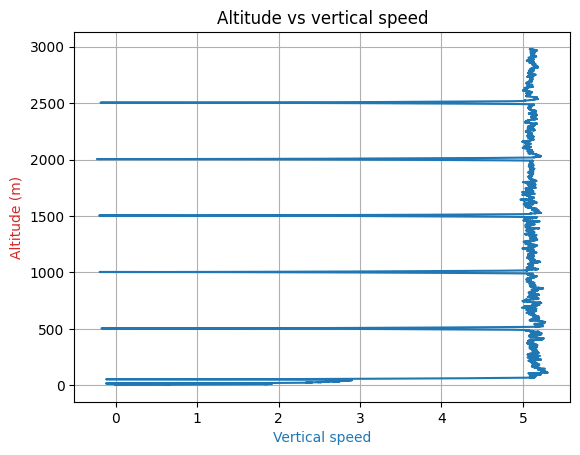

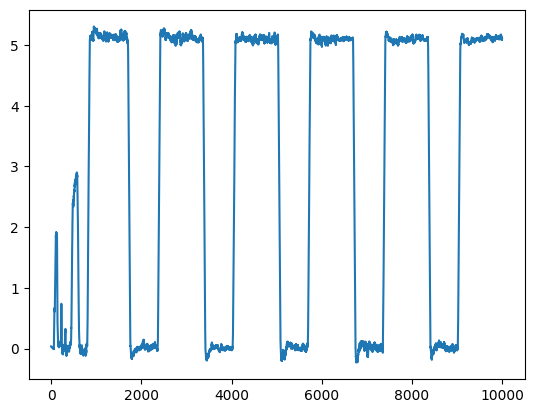

In [30]:

vel = -np.array(data['XKF1_0']['VD'])
vel2 = vel[:len(pressure2)]
t = 0
for i in range(1, pressure2.size):
    if vel2[i] > 0.1:
        t += 1
        if t == 500:
            as_start = i - 499
            break

t = 0
for i in range(as_start, pressure2.size):
    if vel2[i] < 0.1:
        t += 1
        if t == 500:
            as_end = i - 499
            break
print("Ascend start index:", as_start)
print("Ascend end index:", as_end)


plt.figure()
plt.plot(vel2[:10000], alt2[:10000], color='tab:blue')
plt.xlabel('Vertical speed', color='tab:blue')
plt.ylabel('Altitude (m)', color='tab:red')
plt.title('Altitude vs vertical speed')
plt.grid(True)
plt.show()

plt.figure()
plt.plot(vel2[:10000])
plt.show()


In [24]:
hov_start, des_start, des_end = [], [], []
k = a = b = 0
in_hover = False
in_descent = False

for i in range(as_end, vel2.size):

    if not in_hover and -0.2 < vel2[i] < 0.2:
        k += 1
        if k == 10:
            hov_start.append(i - 49)
            k = 0
            in_hover = True
    else:
        k = 0

    if not in_descent and vel2[i] < -2.5:
        a += 1
        if a == 20:
            des_start.append(i - 19)
            a = 0
            in_descent = True
            in_hover = False
    else:
        a = 0

    if in_descent and vel2[i] > -2.5:
        b += 1
        if b == 20:
            des_end.append(i - 19)
            b = 0
            in_descent = False
    else:
        b =0 

print(hov_start)

[6485, 16150]


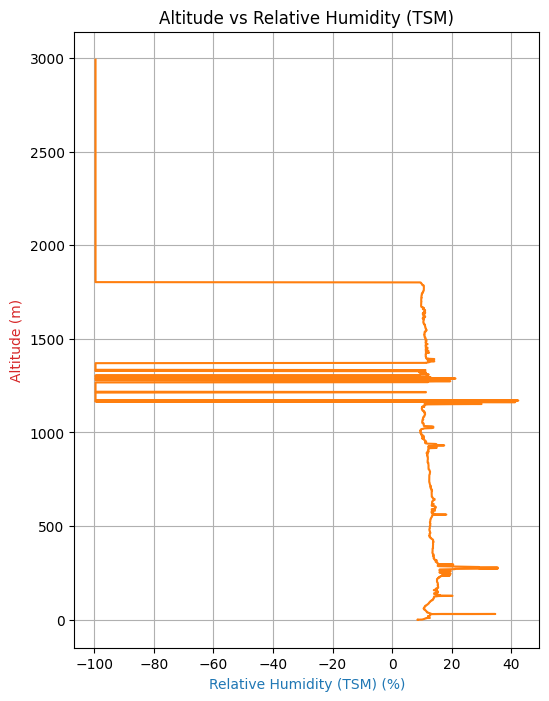

In [15]:
plt.figure(figsize=(6,8))
# plt.figure()
# # plt.plot(temp2[as_end:], -alt2[as_end:], color='tab:blue')
# plt.plot(rh_tsm2[:as_end], -alt2[:as_end], color='tab:blue')
plt.plot(wind2[:as_end], alt2[:as_end], color='tab:orange')
# plt.xlim(10, 40)
plt.xlabel('Relative Humidity (TSM) (%)', color='tab:blue')
plt.ylabel('Altitude (m)', color='tab:red')
plt.title('Altitude vs Relative Humidity (TSM)')
plt.grid(True)
plt.show()

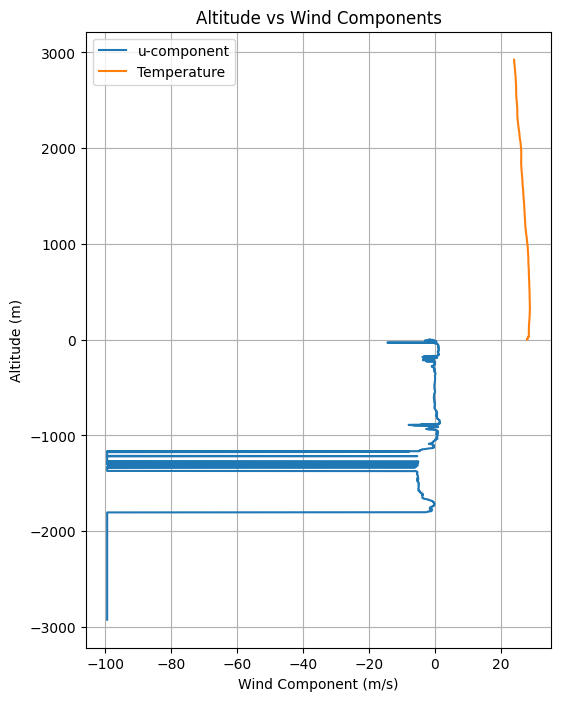

In [16]:
plt.figure(figsize=(6,8))
plt.plot(u_vector2[:6350], -alt2[:6350], label='u-component')
plt.plot(temp2[:6350], alt2[:6350], label='Temperature')
# # plt.plot(v_vector2[:6350], -alt2[:6350], label='v-component')
# plt.plot(w_vector2[:6350], -alt2[:6350], label='w-component')

plt.xlabel('Wind Component (m/s)')
plt.ylabel('Altitude (m)')
plt.title('Altitude vs Wind Components')
plt.legend()
plt.grid(True)
plt.show()

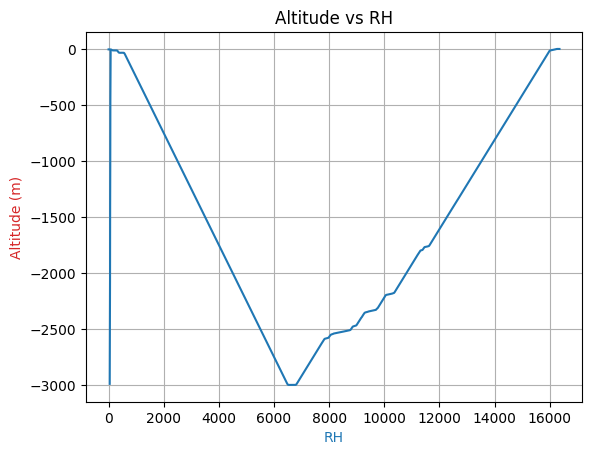

In [13]:
plt.figure()
plt.plot(rh2[as_start:as_end], -1*alt2[as_start:as_end], color='tab:blue')
plt.xlabel('RH', color='tab:blue')
plt.ylabel('Altitude (m)', color='tab:red')
plt.title('Altitude vs RH')
plt.grid(True)
# plt.show()

plt.plot(alt)